# Exploring sampled gist

- based on the experiments from done on bert experiment with different values of nlist, k, and calibration data size

In [1]:
# configuration constants
ALPHA = 0.1
DATASET = "glove30k"

# NLIST_GEN_LOWER_BOUND = 70000 # 5000
# NLIST_GEN_UPPER_BOUND = 100000 # 55000
# NLIST_GEN_NUMBER_STEPS = 3 # 50

# K_LOWER_BOUND = 100 # 20
# K_UPPER_BOUND = 600 # 1020
# K_NUMBER_STEPS = 5 # 50

range_nlist = [50, 111, 150, 180, 250]
range_nlist_computed = []
range_calib = [0.9, 0.7, 0.5, 0.3, 0.1]
range_k = [100, 300, 500]

In [3]:
range_nlist_to_compute = list(set(range_nlist) - set(range_nlist_computed))
range_nlist_to_compute.sort()
range_nlist_to_compute

[50, 111, 150, 180, 250]

In [3]:
import subprocess
import os

env = os.environ.copy()
env["OMP_NUM_THREADS"] = "8"

def run_conann(dataset, calib, alpha, nlist, k):
    print("running conann on: ", dataset, calib, alpha, nlist, k)
    subprocess.run(["./build/eval/error", dataset, str(calib), str(alpha), str(nlist), str(k)], 
                           capture_output=True, 
                           text=False,
                           cwd=os.path.abspath("../conann"),
                           check=True)

def run_faiss(dataset, calib, nlist, k, starting_nprobe, alpha):
    print("running faiss on: ", dataset, calib, nlist, k, starting_nprobe, alpha)
    result = subprocess.run(["./build/eval/error", dataset, str(calib), str(nlist), str(k), str(starting_nprobe), str(alpha)], 
                           capture_output=True, 
                           text=True,
                           cwd=os.path.abspath("../faiss-1.9.0"),
                           check=True)
    return result.stdout.splitlines()[-1]

    

## Run conann with different parameters

compare nlist and k

In [4]:
for nlist, k in [(n, k) for n in range_nlist_to_compute for k in range_k]:
    run_conann(DATASET, 0.5, ALPHA, nlist, k)

running conann on:  glove30k 0.5 0.1 50 100
running conann on:  glove30k 0.5 0.1 50 300
running conann on:  glove30k 0.5 0.1 50 500
running conann on:  glove30k 0.5 0.1 111 100
running conann on:  glove30k 0.5 0.1 111 300
running conann on:  glove30k 0.5 0.1 111 500
running conann on:  glove30k 0.5 0.1 150 100
running conann on:  glove30k 0.5 0.1 150 300
running conann on:  glove30k 0.5 0.1 150 500
running conann on:  glove30k 0.5 0.1 180 100
running conann on:  glove30k 0.5 0.1 180 300
running conann on:  glove30k 0.5 0.1 180 500
running conann on:  glove30k 0.5 0.1 250 100
running conann on:  glove30k 0.5 0.1 250 300
running conann on:  glove30k 0.5 0.1 250 500


compare nlist and calib at K100

In [5]:
for nlist, calib in [(n, c) for n in range_nlist_to_compute for c in range_calib]:
    run_conann(DATASET, calib, ALPHA, nlist, 100)

running conann on:  glove30k 0.9 0.1 50 100
running conann on:  glove30k 0.7 0.1 50 100
running conann on:  glove30k 0.5 0.1 50 100
running conann on:  glove30k 0.3 0.1 50 100
running conann on:  glove30k 0.1 0.1 50 100
running conann on:  glove30k 0.9 0.1 111 100
running conann on:  glove30k 0.7 0.1 111 100
running conann on:  glove30k 0.5 0.1 111 100
running conann on:  glove30k 0.3 0.1 111 100
running conann on:  glove30k 0.1 0.1 111 100
running conann on:  glove30k 0.9 0.1 150 100
running conann on:  glove30k 0.7 0.1 150 100
running conann on:  glove30k 0.5 0.1 150 100
running conann on:  glove30k 0.3 0.1 150 100
running conann on:  glove30k 0.1 0.1 150 100
running conann on:  glove30k 0.9 0.1 180 100
running conann on:  glove30k 0.7 0.1 180 100
running conann on:  glove30k 0.5 0.1 180 100
running conann on:  glove30k 0.3 0.1 180 100
running conann on:  glove30k 0.1 0.1 180 100
running conann on:  glove30k 0.9 0.1 250 100
running conann on:  glove30k 0.7 0.1 250 100
running conann 

baseline values for nlist and k

In [6]:
for nlist in range_nlist_to_compute:
    starting_nprobe = 6
    for k in range_k:
        next_starting_nprobe = run_faiss(DATASET, 0.5, nlist, k, starting_nprobe, ALPHA)
        print("next starting nprobe: ", next_starting_nprobe)
        starting_nprobe = int(next_starting_nprobe) - 5

running faiss on:  glove30k 0.5 50 100 6 0.1
next starting nprobe:  11
running faiss on:  glove30k 0.5 50 300 6 0.1
next starting nprobe:  13
running faiss on:  glove30k 0.5 50 500 8 0.1
next starting nprobe:  13
running faiss on:  glove30k 0.5 111 100 6 0.1
next starting nprobe:  23
running faiss on:  glove30k 0.5 111 300 18 0.1
next starting nprobe:  26
running faiss on:  glove30k 0.5 111 500 21 0.1
next starting nprobe:  27
running faiss on:  glove30k 0.5 150 100 6 0.1
next starting nprobe:  29
running faiss on:  glove30k 0.5 150 300 24 0.1
next starting nprobe:  32
running faiss on:  glove30k 0.5 150 500 27 0.1
next starting nprobe:  33
running faiss on:  glove30k 0.5 180 100 6 0.1
next starting nprobe:  30
running faiss on:  glove30k 0.5 180 300 25 0.1
next starting nprobe:  33
running faiss on:  glove30k 0.5 180 500 28 0.1
next starting nprobe:  34
running faiss on:  glove30k 0.5 250 100 6 0.1
next starting nprobe:  36
running faiss on:  glove30k 0.5 250 300 31 0.1
next starting 

## Analyse Results

In [4]:
range_nlist = list(set(range_nlist_computed) | set(range_nlist_to_compute))
range_nlist.sort()
range_nlist

[50, 111, 150, 180, 250]

In [5]:
avg_vec_in_cluster = [30000/x for x in range_nlist]
avg_vec_in_cluster

[600.0, 270.27027027027026, 200.0, 166.66666666666666, 120.0]

In [6]:
import numpy as np

def read_float(filename: str) -> np.array:
    # filename = glob.glob(filename)[0]

    data=[]
    with open(filename, 'r') as f:
        tmpstr = f.readline()
        while (tmpstr):
            data.append(float(tmpstr))
            tmpstr = f.readline()
    return np.array(data)

In [7]:
def import_from_logs(program: str, topic: str, dataset: str, nlist, k, calib = 0.5, alpha: float = 0.1) -> np.array:
    if (program == "ConANN"):
        return read_float(f"../{program}-{topic}-{dataset}-{nlist}-{k}-{alpha}-{calib}.log")
    else:
        return read_float(f"../{program}-{topic}-{dataset}-{nlist}-{k}-{alpha}.log")

# Experiment 1: nlist and k

## Results conann average

In [8]:
results_conann_avg = np.empty(shape=(len(range_nlist), len(range_k)))
# for nlist, k in [(n, k) for n in range_nlist for k in range_k]:
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_k)):
        clusters_searched = import_from_logs("ConANN", "efficiency", DATASET, range_nlist[i], range_k[j])
        results_conann_avg[i][j] = np.average(clusters_searched)

In [9]:
display(results_conann_avg)

array([[12.9272, 13.8504, 14.086 ],
       [28.1968, 31.926 , 33.1556],
       [31.8268, 35.898 , 37.3076],
       [37.664 , 42.8412, 44.6304],
       [46.5664, 53.7384, 56.4048]])

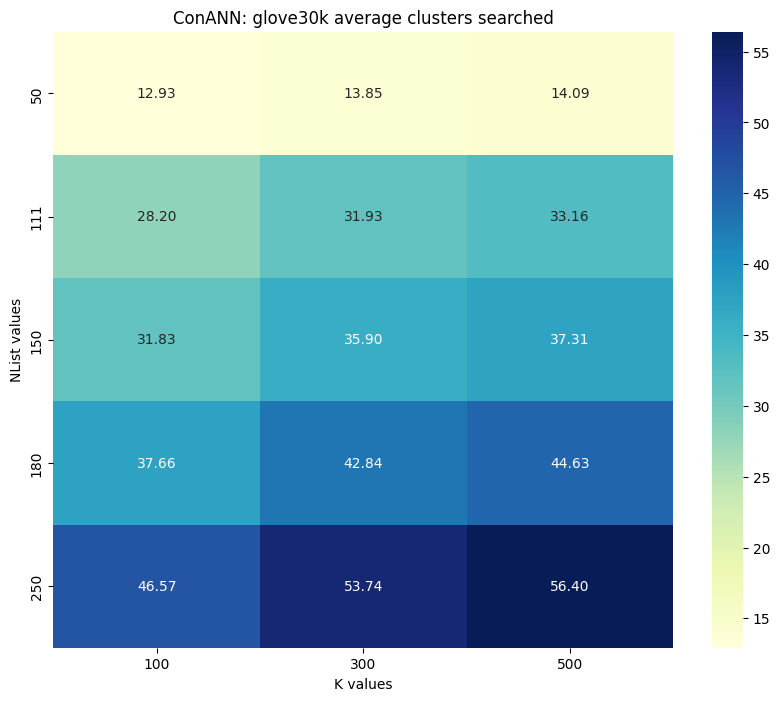

In [10]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_avg, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title(f"ConANN: {DATASET} average clusters searched")
plt.show()

In [11]:
results_conann_no_threshold = np.empty(shape=(len(range_nlist), len(range_k)))
# for nlist, k in [(n, k) for n in range_nlist for k in range_k]:
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_k)):
        clusters_searched = import_from_logs("ConANN", "efficiency", DATASET, range_nlist[i], range_k[j])
        results_conann_no_threshold[i][j] = np.count_nonzero(clusters_searched == -1)

In [12]:
display(results_conann_no_threshold)

array([[182., 163., 138.],
       [148., 112.,  81.],
       [151., 108.,  78.],
       [152., 121.,  78.],
       [137.,  86.,  56.]])

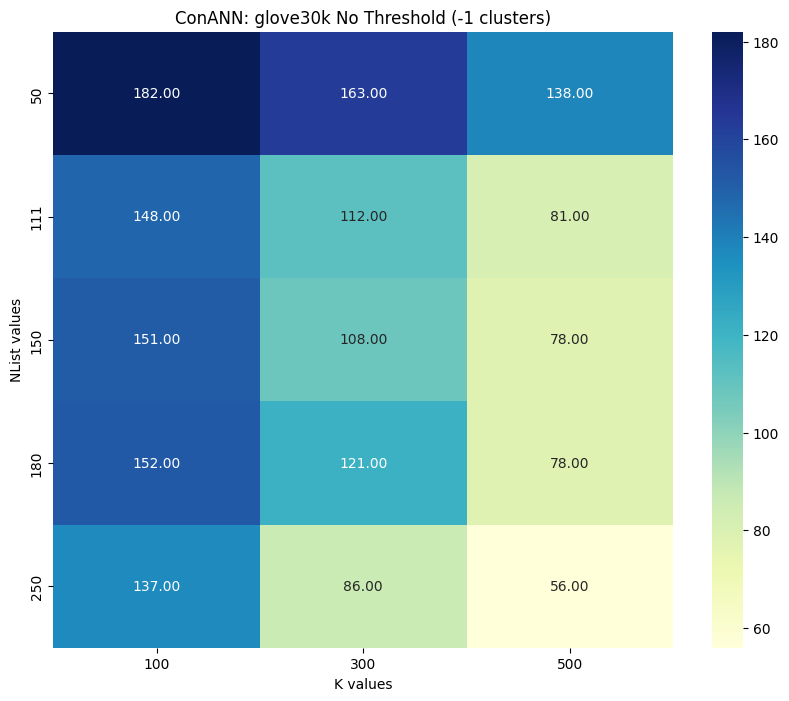

In [13]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_no_threshold, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title(f'ConANN: {DATASET} No Threshold (-1 clusters)')
plt.show()

## results faiss

In [14]:
results_faiss = np.empty(shape=(len(range_nlist), len(range_k)))
# for nlist, k in [(n, k) for n in range_nlist for k in range_k]:
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_k)):
        clusters_searched = import_from_logs("Faiss", "efficiency", DATASET, range_nlist[i], range_k[j])
        results_faiss[i][j] = clusters_searched[0]

In [15]:
display(results_faiss)

array([[11., 13., 13.],
       [23., 26., 27.],
       [29., 32., 33.],
       [30., 33., 34.],
       [36., 40., 43.]])

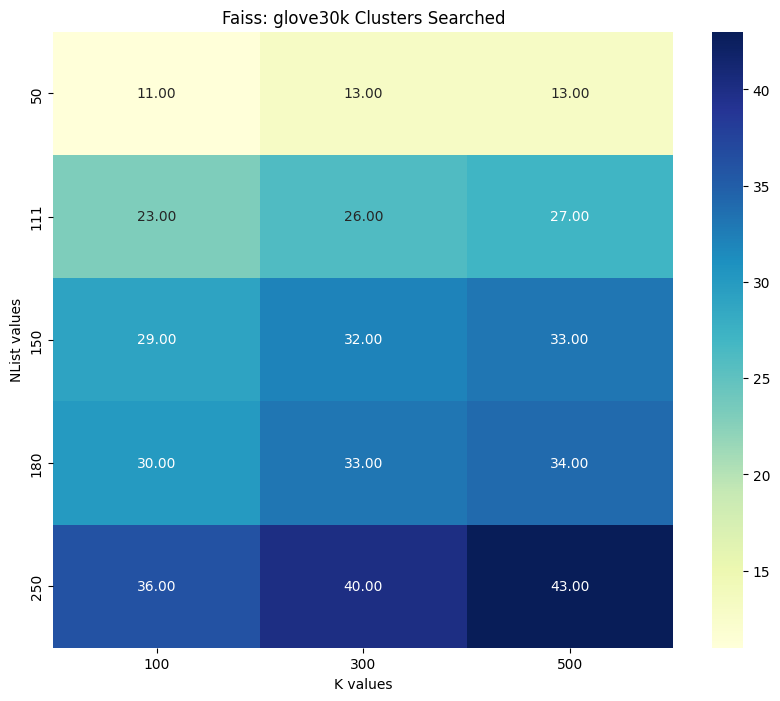

In [16]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_faiss, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title(f'Faiss: {DATASET} Clusters Searched')
plt.show()

## compare

In [17]:
comparison = (results_conann_avg - results_faiss) / results_faiss * 100

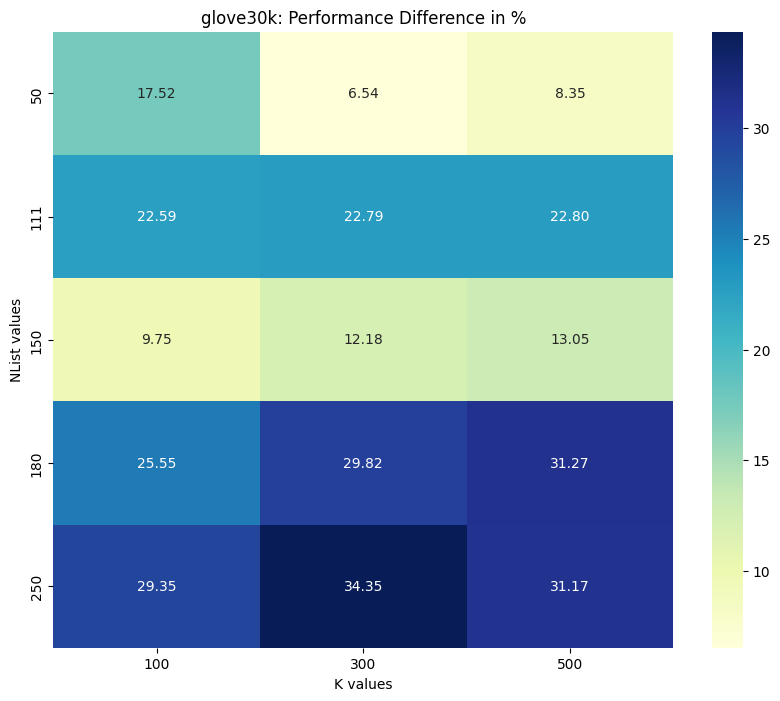

In [18]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(comparison, annot=True, fmt=".2f", xticklabels=range_k, yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('K values')
plt.ylabel('NList values')
plt.title(f'{DATASET}: Performance Difference in %')
plt.show()

# Experiment 2: nlist and calib

In [19]:
results_conann_calib = np.empty(shape=(len(range_nlist), len(range_calib)))
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_calib)):
        clusters_searched = import_from_logs("ConANN", "efficiency", DATASET, range_nlist[i], 100, range_calib[j])
        results_conann_calib[i][j] = np.average(clusters_searched)

In [20]:
display(results_conann_calib)

array([[13.014     , 12.96      , 12.9272    , 13.11      , 13.31911111],
       [27.918     , 27.81733333, 28.1968    , 28.30114286, 28.70111111],
       [32.018     , 31.634     , 31.8268    , 32.12685714, 32.63977778],
       [37.806     , 37.84666667, 37.664     , 37.98742857, 37.86266667],
       [45.916     , 46.18266667, 46.5664    , 47.15542857, 47.66822222]])

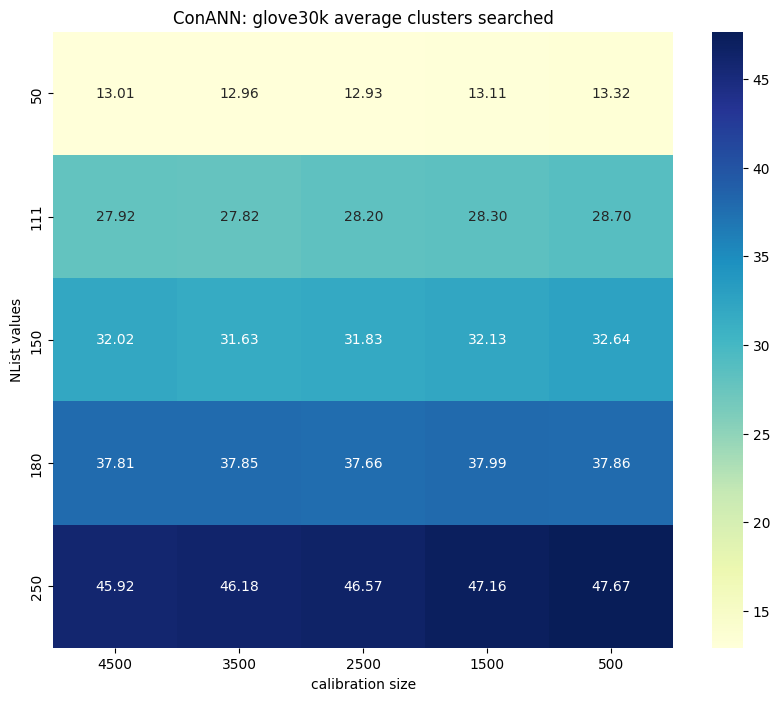

In [21]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_calib, annot=True, fmt=".2f", xticklabels=[int(x * 5000) for x in range_calib], yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('calibration size')
plt.ylabel('NList values')
plt.title(f'ConANN: {DATASET} average clusters searched')
plt.show()

In [22]:
results_conann_calib_no_threshold = np.empty(shape=(len(range_nlist), len(range_calib)))
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_calib)):
        clusters_searched = import_from_logs("ConANN", "efficiency", DATASET, range_nlist[i], 100, range_calib[j])
        results_conann_calib_no_threshold[i][j] = np.count_nonzero(clusters_searched == -1)

In [23]:
display(results_conann_calib_no_threshold)

array([[ 32., 107., 182., 230., 244.],
       [ 31.,  97., 148., 191., 189.],
       [ 32.,  96., 151., 187., 206.],
       [ 35.,  93., 152., 195., 253.],
       [ 34.,  96., 137., 157., 164.]])

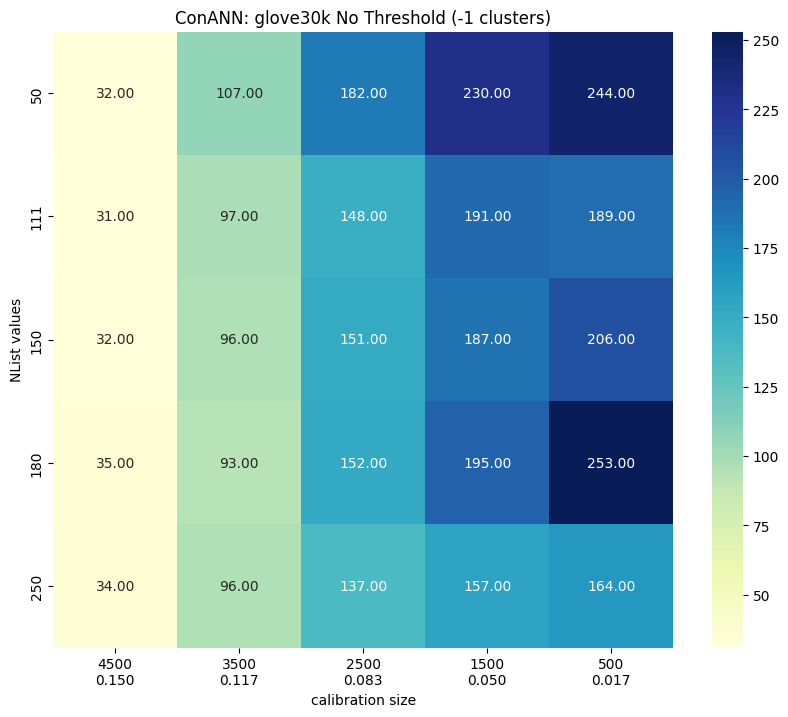

In [24]:
import seaborn as sns

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(results_conann_calib_no_threshold, annot=True, fmt=".2f", xticklabels=[f"{int(x * 5000)}\n{float(x*5000/30000):.3f}" for x in range_calib], yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('calibration size')
plt.ylabel('NList values')
plt.title(f'ConANN: {DATASET} No Threshold (-1 clusters)')
plt.show()

In [25]:
validity_conann_calib = np.empty(shape=(len(range_nlist), len(range_calib)))
for i in range(0, len(range_nlist)):
    for j in range(0, len(range_calib)):
        fnrs = import_from_logs("ConANN", "error", DATASET, range_nlist[i], 100, range_calib[j])
        validity_conann_calib[i][j] = np.average(fnrs)

In [26]:
display(validity_conann_calib)

array([[0.09524   , 0.09747333, 0.09722   , 0.08688857, 0.07296444],
       [0.09636   , 0.10226   , 0.091796  , 0.08669714, 0.07300444],
       [0.09196   , 0.10613333, 0.102628  , 0.09337429, 0.07995111],
       [0.09474   , 0.09326667, 0.096704  , 0.09022   , 0.09185778],
       [0.09682   , 0.09457333, 0.089812  , 0.07949714, 0.06961556]])

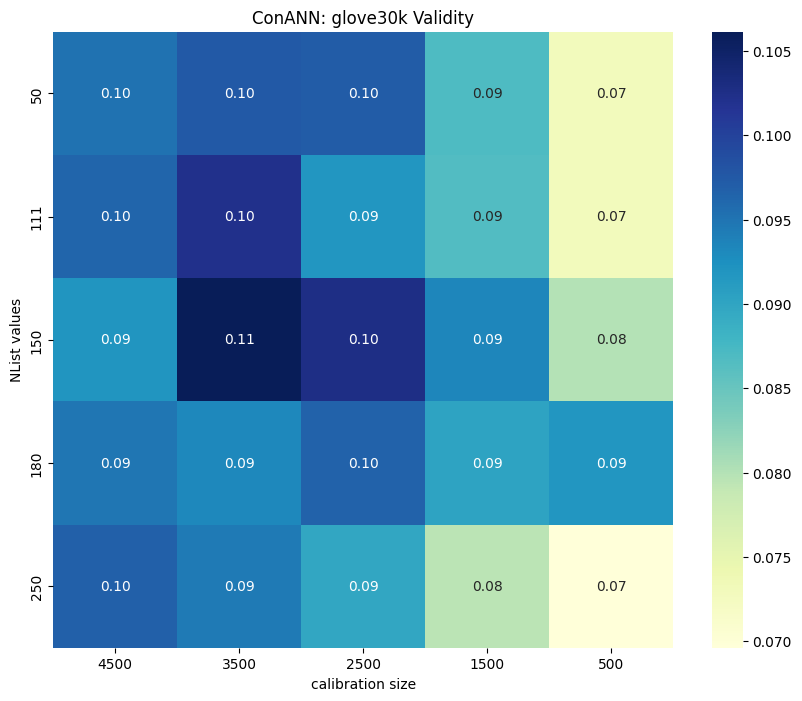

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(validity_conann_calib, annot=True, fmt=".2f", xticklabels=[int(x * 5000) for x in range_calib], yticklabels=range_nlist, cmap="YlGnBu")
plt.xlabel('calibration size')
plt.ylabel('NList values')
plt.title(f'ConANN: {DATASET} Validity')
plt.show()
